## Q4: Do Blue Jays pitchers lose velocity, command, or effectiveness as games progress?

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Data_MLB_2025_StatcastPostseason_PitchByPitch_20251102a.csv")
df.head()

,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.0,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.0,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.0,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,0.043,NaN,NaN


## Data Type & Missing Values

In [12]:
df.shape
df.columns
df.info()
df.isnull().sum().sort_values(ascending=False)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14096 entries, 0 to 14095
Data columns (total 95 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   game_year                        14096 non-null  int64  
 1   game_date                        14096 non-null  object 
 2   player_name                      14096 non-null  object 
 3   pitcher                          14096 non-null  int64  
 4   batter                           14096 non-null  int64  
 5   balls                            14096 non-null  int64  
 6   strikes                          14096 non-null  int64  
 7   inning                           14096 non-null  int64  
 8   inning_topbot                    14096 non-null  object 
 9   at_bat_number                    14096 non-null  int64  
 10  pitch_number                     14096 non-null  int64  
 11  events                           3602 non-null   object 
 12  pitch_type        

,game_year,pitcher,batter,balls,strikes,inning,at_bat_number,pitch_number,release_speed,release_pos_x,...,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
count,14096.0,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,...,14096.000000,14096.00000,14096.000000,14096.000000,14096.000000,14089.000000,14096.000000,14096.000000,6704.000000,6704.000000
mean,2025.0,654432.648127,646575.503689,0.872375,0.916359,5.273624,40.607406,2.925227,90.682740,-0.796971,...,2.110031,1.94431,2.223184,2.057463,2.110031,176.305203,0.000167,-0.002535,69.569391,7.244824
std,0.0,60782.502545,49297.380592,0.968588,0.829502,3.027925,25.720786,1.741043,6.008374,1.893833,...,2.523059,2.20987,2.625899,2.334641,2.523059,74.953615,0.027601,0.222230,9.545128,1.054472
min,2025.0,453286.000000,457759.000000,0.000000,0.000000,1.000000,1.000000,1.000000,69.200000,-4.330000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,-0.509000,-0.530000,2.000000,0.500000
25%,2025.0,608718.000000,608701.000000,0.000000,0.000000,3.000000,20.000000,1.000000,86.200000,-2.160000,...,0.000000,0.00000,0.000000,0.000000,0.000000,132.000000,0.000000,-0.063000,67.100000,6.600000
50%,2025.0,666200.000000,664023.000000,1.000000,1.000000,5.000000,39.000000,3.000000,91.600000,-1.600000,...,1.000000,1.00000,1.000000,1.000000,1.000000,201.000000,0.000000,-0.039000,71.200000,7.300000
75%,2025.0,682120.000000,676391.000000,1.000000,2.000000,7.000000,59.000000,4.000000,95.700000,1.040000,...,3.000000,3.00000,3.000000,3.000000,3.000000,222.000000,0.000000,0.039000,74.600000,8.000000
max,2025.0,813349.000000,807799.000000,3.000000,2.000000,18.000000,153.000000,13.000000,104.500000,4.100000,...,13.000000,13.00000,13.000000,13.000000,13.000000,360.000000,0.412000,2.696000,87.600000,10.400000


## Feature

### velocity

In [30]:
df['velocity'] = df['release_speed']

### command: strike rate

In [52]:
df['is_strike'] = df['description'].isin([
    'called_strike',
    'swinging_strike',
    'swinging_strike_blocked',
    'foul',
    'foul_tip',
    'foul_bunt',
    'hit_into_play'
]).astype(int)

strike_rate = df['is_strike'].mean()

### effectiveness: whiff rate

In [54]:
df['is_whiff'] = df['description'].isin([
    'swinging_strike',
    'swinging_strike_blocked'
]).astype(int)

whiff_rate = df['is_whiff'].mean()

### 2. 

### game progression : inning

In [33]:
def inning_group(inning):
    if inning <= 3:
        return "early"
    elif inning <= 6:
        return "mid"
    else:
        return "late"

df['game_stage'] = df['inning'].apply(inning_group)

## Basic Distribution

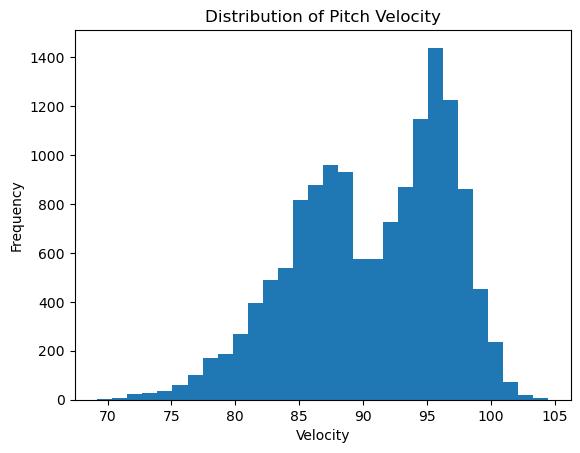

In [61]:
plt.hist(df['velocity'].dropna(), bins=30)
plt.title("Distribution of Pitch Velocity")
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.show()

In [63]:
df['is_strike'].mean()

0.6467082860385925

In [65]:
df['is_whiff'].mean()

0.12507094211123723

In [67]:
df.groupby('inning')[['velocity', 'is_strike', 'is_whiff']].mean()

,velocity,is_strike,is_whiff
inning,,,
1,91.090458,0.653036,0.135688
2,90.699731,0.663533,0.138348
3,90.221534,0.654778,0.137281
4,89.935648,0.631614,0.121032
5,90.236686,0.667139,0.125354
6,90.736808,0.642214,0.123552
7,90.941543,0.641975,0.116049
8,90.945538,0.628923,0.107692
9,91.374795,0.641492,0.125569


## Time Progression Analysis

In [73]:
# Average for every inning
inning_stats = df.groupby('inning')[['velocity', 'is_strike', 'is_whiff']].mean()
inning_stats

,velocity,is_strike,is_whiff
inning,,,
1,91.090458,0.653036,0.135688
2,90.699731,0.663533,0.138348
3,90.221534,0.654778,0.137281
4,89.935648,0.631614,0.121032
5,90.236686,0.667139,0.125354
6,90.736808,0.642214,0.123552
7,90.941543,0.641975,0.116049
8,90.945538,0.628923,0.107692
9,91.374795,0.641492,0.125569


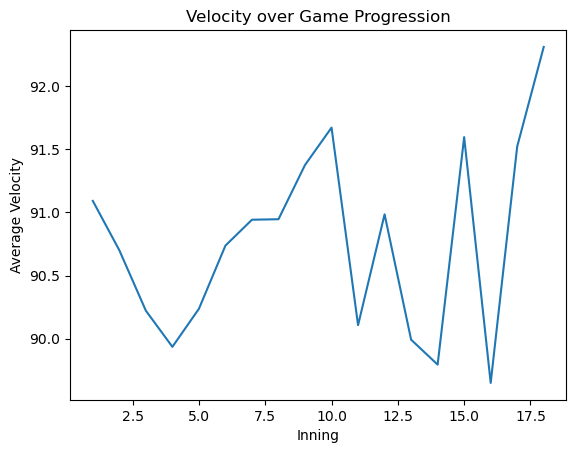

In [77]:
# Change of velocity
plt.plot(inning_stats.index, inning_stats['velocity'])
plt.xlabel("Inning")
plt.ylabel("Average Velocity")
plt.title("Velocity over Game Progression")
plt.show()

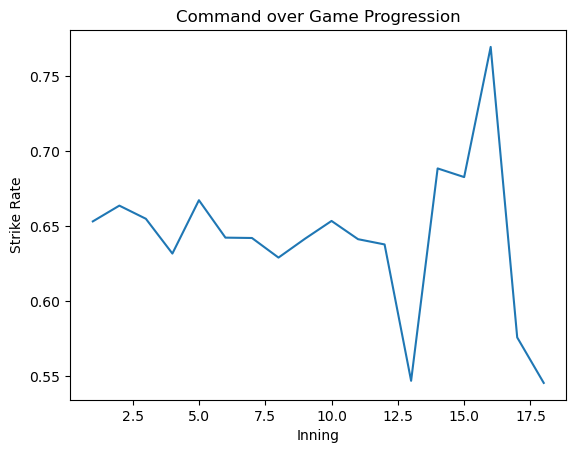

In [79]:
# Change of Command
plt.plot(inning_stats.index, inning_stats['is_strike'])
plt.xlabel("Inning")
plt.ylabel("Strike Rate")
plt.title("Command over Game Progression")
plt.show()

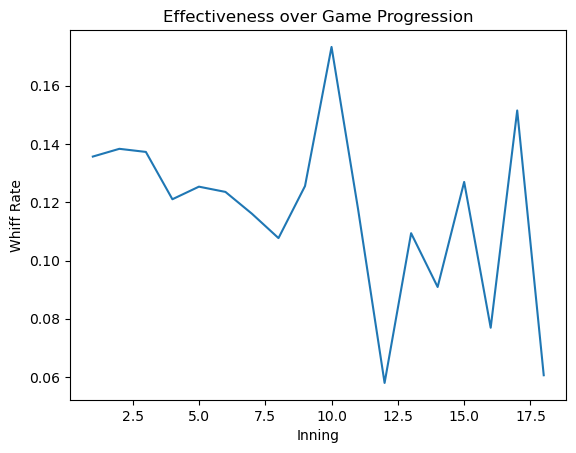

In [81]:
# Change of effectiveness
plt.plot(inning_stats.index, inning_stats['is_whiff'])
plt.xlabel("Inning")
plt.ylabel("Whiff Rate")
plt.title("Effectiveness over Game Progression")
plt.show()

## Early / Late

In [85]:
# inning : early / mid / late
def inning_group(inning):
    if inning <= 3:
        return "early"
    elif inning <= 6:
        return "mid"
    else:
        return "late"

df['stage'] = df['inning'].apply(inning_group)

In [87]:
stage_stats = df.groupby('stage')[['velocity', 'is_strike', 'is_whiff']].mean()
stage_stats

,velocity,is_strike,is_whiff
stage,,,
early,90.682306,0.657006,0.137067
late,91.016286,0.637502,0.115729
mid,90.308598,0.646494,0.123269


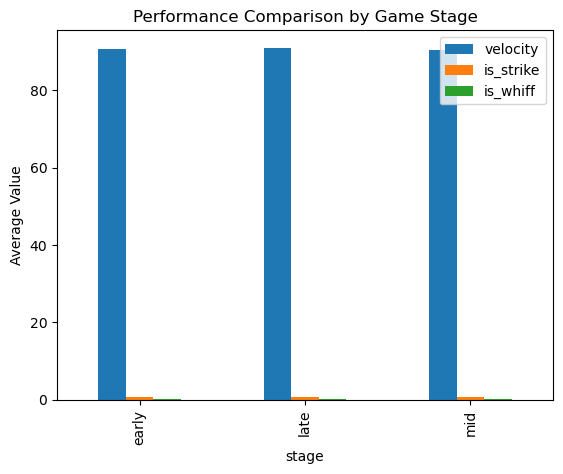

In [91]:
stage_stats.plot(kind='bar')
plt.title("Performance Comparison by Game Stage")
plt.ylabel("Average Value")
plt.show()